In [1]:
%matplotlib inline

<h3>Importando, normalizando e visualizando os dados</h3>

In [2]:
# Quantum vs Classical Classification on Iris Dataset

import timeit
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from itertools import cycle
from prettytable import prettytable

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, recall_score, f1_score, confusion_matrix,
    roc_curve, auc, roc_auc_score, multilabel_confusion_matrix
)
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

from qiskit.circuit.library import ZFeatureMap, ZZFeatureMap, RealAmplitudes
from qiskit.circuit.library import RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit import Aer
from qiskit_machine_learning.algorithms.classifiers import VQC

<h3>Train Test Split</h3>

In [4]:
# Step 1: Load and preprocess the Iris dataset
iris_data = load_iris()
features = iris_data.data
labels = iris_data.target

<h3>Função para treinar o classificador clássico</h3>

In [6]:
# Normalize the features
features = MinMaxScaler().fit_transform(features)

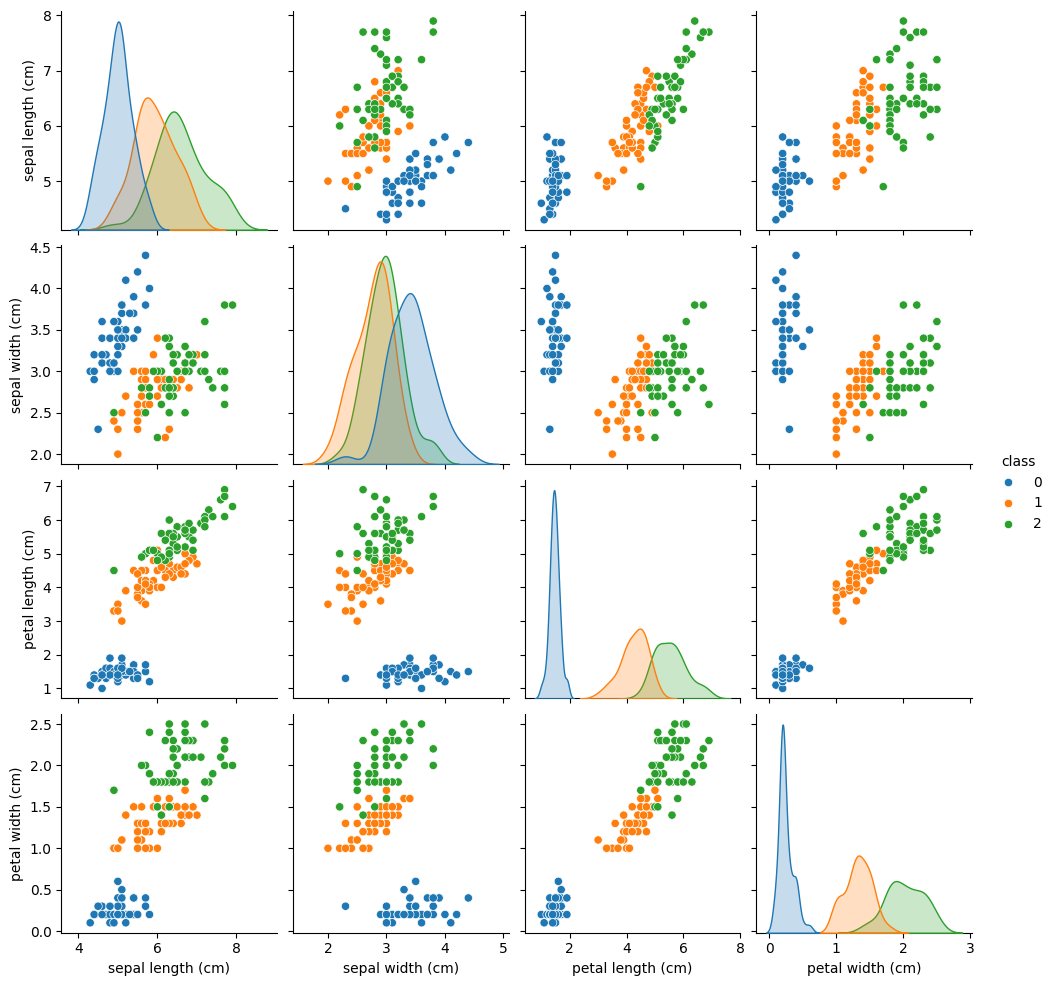

In [7]:
# Visualize the dataset
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df["class"] = pd.Series(iris_data.target)
sns.pairplot(df, hue="class", palette="tab10")
plt.show()

<h3>Data Encoding</h3>

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

# Step 1: Train-Test Split
TTS_seed = 123
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, random_state=TTS_seed
)

# Step 2: One-hot encode the labels
n_classes = len(np.unique(labels))  # Número de classes únicas
train_labels_encoded = label_binarize(train_labels, classes=range(n_classes))
test_labels_encoded = label_binarize(test_labels, classes=range(n_classes))

<h3>Ansatz: o circuito quântico variacional</h3>

In [10]:
# Step 3: Define Quantum Feature Maps
# ZFeatureMap for linear feature encoding
z_feature_map = ZFeatureMap(feature_dimension=features.shape[1], reps=1)

# ZZFeatureMap for entangled feature encoding
zz_feature_map = ZZFeatureMap(feature_dimension=features.shape[1], reps=2)


<h3>Escolha do Otimizador</h3>

ZFeatureMap Circuit:


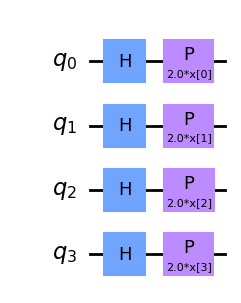

ZZFeatureMap Circuit:


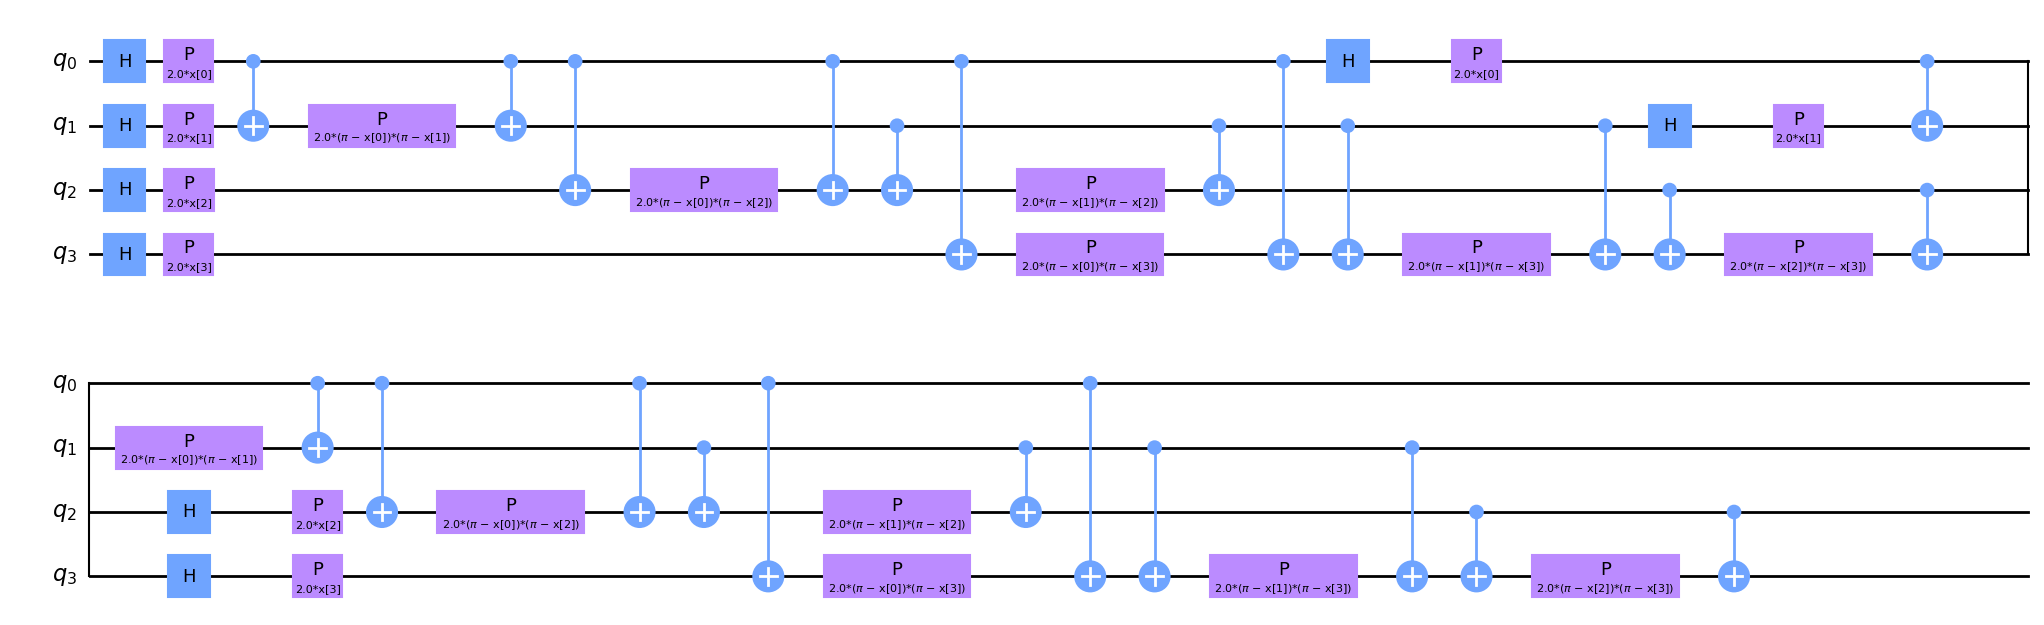

Ansatz Circuit:


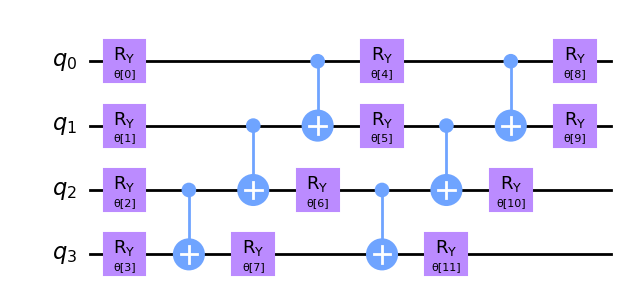

In [11]:
# Step 3: Define Quantum Feature Maps
# ZFeatureMap for linear feature encoding
z_feature_map = ZFeatureMap(feature_dimension=features.shape[1], reps=1)

# ZZFeatureMap for entangled feature encoding
zz_feature_map = ZZFeatureMap(feature_dimension=features.shape[1], reps=2)

# Visualize the feature maps
print("ZFeatureMap Circuit:")
z_feature_map.decompose().draw(output="mpl", fold=30)
plt.show()

print("ZZFeatureMap Circuit:")
zz_feature_map.decompose().draw(output="mpl", fold=30)
plt.show()

# Step 4: Ansatz for Variational Quantum Classifier (VQC)
var_circuit = RealAmplitudes(num_qubits=features.shape[1], reps=2)
print("Ansatz Circuit:")
var_circuit.decompose().draw(output="mpl", fold=30)
plt.show()

<h3>Definindo a callback</h3>

<h3>Função para treinar o classificador quântico</h3>

In [12]:
# Step 6: Define Classic SVM Training Function
def train_classic_classifier():
    svc_classic = OneVsRestClassifier(SVC(kernel="linear", max_iter=100, probability=True))
    svc_classic.fit(train_features, train_labels)
    return svc_classic


<h3>Medindo o tempo de execução</h3>

In [13]:
# Step 7: Define Quantum Classifier Training Function (VQC)
optimizer = COBYLA(maxiter=100)


<h3>Avaliando os classificadores</h3>

In [14]:
def train_vqc_classifier():
    vqc = VQC(
        feature_map=zz_feature_map,
        ansatz=var_circuit,
        optimizer=optimizer,
        quantum_instance=Aer.get_backend('aer_simulator_statevector')
    )
    # Use the one-hot encoded labels for training
    vqc.fit(train_features, train_labels_encoded)
    return vqc

In [15]:
# Step 8: Train and Evaluate Classifiers
# Classic SVM
start_time_classic = timeit.default_timer()
svc_classic = train_classic_classifier()
end_time_classic = timeit.default_timer()
time_classic = end_time_classic - start_time_classic

# Quantum VQC
start_time_vqc = timeit.default_timer()
vqc = train_vqc_classifier()
end_time_vqc = timeit.default_timer()
time_vqc = end_time_vqc - start_time_vqc

# Quantum Kernel-based SVM
start_time_qsvm = timeit.default_timer()
qsvm = SVC(kernel=quantum_kernel.evaluate)
qsvm.fit(train_features, train_labels)
end_time_qsvm = timeit.default_timer()
time_qsvm = end_time_qsvm - start_time_qsvm


MissingOptionalLibraryError: "The 'qiskit-aer' library is required to use 'Aer provider'. You can install it with 'pip install qiskit-aer'."

In [65]:
# Step 9: Predictions and Metrics
# Predictions for Classic SVM
train_preds_classic = svc_classic.predict(train_features)
test_preds_classic = svc_classic.predict(test_features)

# Predictions for VQC
train_preds_vqc = vqc.predict(train_features)
test_preds_vqc = vqc.predict(test_features)

# Predictions for QSVM
train_preds_qsvm = qsvm.predict(train_features)
test_preds_qsvm = qsvm.predict(test_features)

In [66]:
# Step 10: Compute Metrics
def compute_metrics(model_name, train_labels, test_labels, train_preds, test_preds, train_time):
    print(f"\nMetrics for {model_name}:")
    print(f"Training Time: {train_time:.2f} seconds")
    print("Training Classification Report:")
    print(classification_report(train_labels, train_preds, digits=4))
    print("Testing Classification Report:")
    print(classification_report(test_labels, test_preds, digits=4))
    print(f"Training Accuracy: {accuracy_score(train_labels, train_preds):.4f}")
    print(f"Testing Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
    print()

<h3>Cálculo das curvas ROC para os classificadores<h3>

In [73]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- Initial Debugging ---
print("=== Initial Debugging ===")
print(f"Shape of train_predicts_classic: {train_predicts_classic.shape}")
print(f"Shape of test_predicts_classic: {test_predicts_classic.shape}")
print(f"Shape of train_predicts_quantum: {train_predicts_quantum.shape}")
print(f"Shape of test_predicts_quantum: {test_predicts_quantum.shape}")
print(f"Unique values in train_labels: {np.unique(train_labels)}")
print(f"Unique values in test_labels: {np.unique(test_labels)}")

# --- Dynamically Set Unique Classes ---
# Combine labels and predictions to find all unique classes
unique_classes = np.unique(
    np.concatenate([
        train_labels, 
        test_labels, 
        np.argmax(test_predicts_classic, axis=1), 
        np.argmax(test_predicts_quantum, axis=1)
    ])
)
print(f"Unique classes across labels and predictions: {unique_classes}")

# --- Binarize Labels ---
train_labels_bin = label_binarize(train_labels, classes=unique_classes)
test_labels_bin = label_binarize(test_labels, classes=unique_classes)

# --- Debugging Shapes ---
print("=== Shapes After Binarization ===")
print(f"Shape of train_labels_bin: {train_labels_bin.shape}")
print(f"Shape of test_labels_bin: {test_labels_bin.shape}")
print(f"Shape of train_predicts_classic: {train_predicts_classic.shape}")
print(f"Shape of test_predicts_classic: {test_predicts_classic.shape}")
print(f"Shape of train_predicts_quantum: {train_predicts_quantum.shape}")
print(f"Shape of test_predicts_quantum: {test_predicts_quantum.shape}")

# --- Validate Input Sizes ---
print("=== Validating Input Sizes ===")
# Align rows (number of samples)
min_samples = min(len(test_labels_bin), len(test_predicts_classic))
test_labels_bin = test_labels_bin[:min_samples]
test_predicts_classic = test_predicts_classic[:min_samples]
test_predicts_quantum = test_predicts_quantum[:min_samples]

# Align classes (number of columns)
if test_labels_bin.shape[1] > test_predicts_classic.shape[1]:
    print("Padding missing classes in classic predictions...")
    missing_classes = test_labels_bin.shape[1] - test_predicts_classic.shape[1]
    test_predicts_classic = np.pad(
        test_predicts_classic, ((0, 0), (0, missing_classes)), mode="constant"
    )
elif test_labels_bin.shape[1] < test_predicts_classic.shape[1]:
    print("Trimming extra classes in classic predictions...")
    test_predicts_classic = test_predicts_classic[:, :test_labels_bin.shape[1]]

if test_labels_bin.shape[1] > test_predicts_quantum.shape[1]:
    print("Padding missing classes in quantum predictions...")
    missing_classes = test_labels_bin.shape[1] - test_predicts_quantum.shape[1]
    test_predicts_quantum = np.pad(
        test_predicts_quantum, ((0, 0), (0, missing_classes)), mode="constant"
    )
elif test_labels_bin.shape[1] < test_predicts_quantum.shape[1]:
    print("Trimming extra classes in quantum predictions...")
    test_predicts_quantum = test_predicts_quantum[:, :test_labels_bin.shape[1]]

# --- Final Validation ---
print(f"Final shape of test_labels_bin: {test_labels_bin.shape}")
print(f"Final shape of test_predicts_classic: {test_predicts_classic.shape}")
print(f"Final shape of test_predicts_quantum: {test_predicts_quantum.shape}")
if test_labels_bin.shape != test_predicts_classic.shape:
    raise ValueError("Mismatch between test_labels_bin and test_predicts_classic shapes!")
if test_labels_bin.shape != test_predicts_quantum.shape:
    raise ValueError("Mismatch between test_labels_bin and test_predicts_quantum shapes!")

# --- Create Dictionaries for ROC and AUC ---
fpr_classic = dict()
tpr_classic = dict()
roc_auc_classic = dict()

fpr_quantum = dict()
tpr_quantum = dict()
roc_auc_quantum = dict()

# --- Calculate ROC and AUC for Each Class ---
print("=== Calculating ROC and AUC ===")
for i in range(len(unique_classes)):
    # Skip classes with no positive samples
    if np.sum(test_labels_bin[:, i]) == 0:
        print(f"Skipping class {i} (no positive samples in test_labels_bin).")
        continue

    # Classic ROC
    fpr_classic[i], tpr_classic[i], _ = roc_curve(test_labels_bin[:, i], test_predicts_classic[:, i])
    roc_auc_classic[i] = auc(fpr_classic[i], tpr_classic[i])

    # Quantum ROC
    fpr_quantum[i], tpr_quantum[i], _ = roc_curve(test_labels_bin[:, i], test_predicts_quantum[:, i])
    roc_auc_quantum[i] = auc(fpr_quantum[i], tpr_quantum[i])

# --- Micro-Average ROC and AUC ---
print("=== Micro-Average ROC and AUC ===")
if np.sum(test_labels_bin) > 0:  # Ensure positive samples exist
    fpr_classic["micro"], tpr_classic["micro"], _ = roc_curve(
        test_labels_bin.ravel(), test_predicts_classic.ravel()
    )
    roc_auc_classic["micro"] = auc(fpr_classic["micro"], tpr_classic["micro"])

    fpr_quantum["micro"], tpr_quantum["micro"], _ = roc_curve(
        test_labels_bin.ravel(), test_predicts_quantum.ravel()
    )
    roc_auc_quantum["micro"] = auc(fpr_quantum["micro"], tpr_quantum["micro"])
else:
    print("Warning: No positive samples in test_labels_bin. Skipping micro-average ROC.")

print("=== Completed ROC and AUC Calculations ===")

=== Initial Debugging ===
Shape of train_predicts_classic: (112, 4)
Shape of test_predicts_classic: (38, 4)
Shape of train_predicts_quantum: (112, 4)
Shape of test_predicts_quantum: (38, 4)
Unique values in train_labels: [0 1]
Unique values in test_labels: [0 1 2]
Unique classes across labels and predictions: [0 1 2]
=== Shapes After Binarization ===
Shape of train_labels_bin: (112, 3)
Shape of test_labels_bin: (38, 3)
Shape of train_predicts_classic: (112, 4)
Shape of test_predicts_classic: (38, 4)
Shape of train_predicts_quantum: (112, 4)
Shape of test_predicts_quantum: (38, 4)
=== Validating Input Sizes ===
Trimming extra classes in classic predictions...
Trimming extra classes in quantum predictions...
Final shape of test_labels_bin: (38, 3)
Final shape of test_predicts_classic: (38, 3)
Final shape of test_predicts_quantum: (38, 3)
=== Calculating ROC and AUC ===
=== Micro-Average ROC and AUC ===
=== Completed ROC and AUC Calculations ===


<h3>Função para calcular a especificidade<h3>

In [74]:
def specificity_score(y_true, y_pred):
    # Obtem a matriz de confusão para cada rótulo
    cms = multilabel_confusion_matrix(y_true, y_pred)

    # Calcula a especificidade para cada rótulo e retorna a média
    specificities = [tn / (tn + fp) if (tn + fp) > 0 else 0 for tn, fp, fn, tp in cms.reshape(-1, 4)]
    return np.mean(specificities)

<h3>Métricas para o classificador clássico</h3>

In [17]:
print("Métricas para o classificador clássico:")

# Convert one-hot encoded predictions to class indices (if needed)
if train_predicts_classic.ndim > 1:  # Check if predictions are one-hot encoded
    print("Converting one-hot encoded predictions to class indices...")
    train_predicts_classic = np.argmax(train_predicts_classic, axis=1)
    test_predicts_classic = np.argmax(test_predicts_classic, axis=1)

# Print training metrics
print("Tempo de treinamento:", time_classic, "segundos")
print("Relatório de classificação (treino):")
print(classification_report(train_labels, train_predicts_classic, digits=4, zero_division=0))  # Suppressing warnings
print("Acurácia (Treino):", accuracy_score(train_labels, train_predicts_classic))

# Print testing metrics
print("Relatório de classificação (teste):")
print(classification_report(test_labels, test_predicts_classic, digits=4, zero_division=0))  # Suppressing warnings
print("Acurácia (Teste):", accuracy_score(test_labels, test_predicts_classic))

Métricas para o classificador clássico:


NameError: name 'train_predicts_classic' is not defined

<h3>Métricas para o classificador quântico</h3>

In [87]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Suppress UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

print("Métricas para o classificador quântico:")

# Convert one-hot encoded predictions to class indices (if needed)
if train_predicts_quantum.ndim > 1:  # Check if predictions are one-hot encoded
    print("Converting one-hot encoded predictions to class indices...")
    train_predicts_quantum = np.argmax(train_predicts_quantum, axis=1)
    test_predicts_quantum = np.argmax(test_predicts_quantum, axis=1)

# Log missing predictions
for class_idx in range(len(np.unique(train_labels))):
    if np.sum(train_predicts_quantum == class_idx) == 0:
        print(f"Warning: No predictions for class {class_idx} in training data.")

for class_idx in range(len(np.unique(test_labels))):
    if np.sum(test_predicts_quantum == class_idx) == 0:
        print(f"Warning: No predictions for class {class_idx} in testing data.")

# Print training metrics
print("Tempo de treinamento:", time_quantum, "segundos")
print("Relatório de classificação (treino):")
print(classification_report(train_labels, train_predicts_quantum, digits=4, zero_division=0))  # Suppress warnings
print("Acurácia (Treino):", accuracy_score(train_labels, train_predicts_quantum))

# Print testing metrics
print("Relatório de classificação (teste):")
print(classification_report(test_labels, test_predicts_quantum, digits=4, zero_division=0))  # Suppress warnings
print("Acurácia (Teste):", accuracy_score(test_labels, test_predicts_quantum))

Métricas para o classificador quântico:
Tempo de treinamento: 27.849073499906808 segundos
Relatório de classificação (treino):
              precision    recall  f1-score   support

           0     0.3036    1.0000    0.4658        34
           1     0.0000    0.0000    0.0000        78

    accuracy                         0.3036       112
   macro avg     0.1518    0.5000    0.2329       112
weighted avg     0.0922    0.3036    0.1414       112

Acurácia (Treino): 0.30357142857142855
Relatório de classificação (teste):
              precision    recall  f1-score   support

           0     0.4211    1.0000    0.5926        16
           1     0.0000    0.0000    0.0000         8
           2     0.0000    0.0000    0.0000        14

    accuracy                         0.4211        38
   macro avg     0.1404    0.3333    0.1975        38
weighted avg     0.1773    0.4211    0.2495        38

Acurácia (Teste): 0.42105263157894735


<h3>Plotando as curvas ROC<h3>

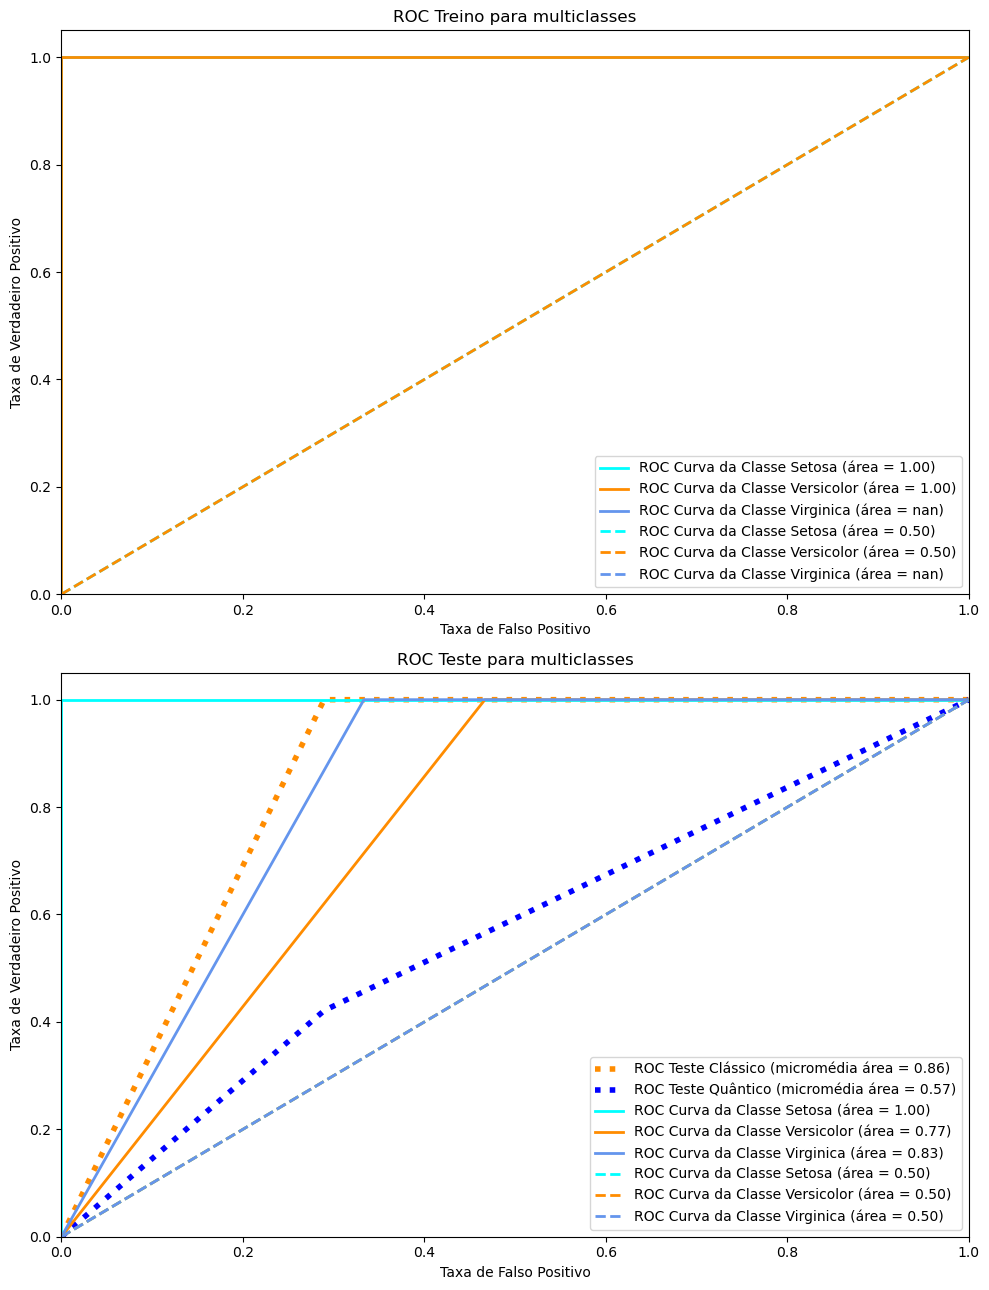

In [90]:
fig, axs = plt.subplots(2, 1, figsize=(10, 13))

# Mapeamento de índices para nomes de classes
class_names = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

# ROC Curvas para treino
if "micro" in fpr_classic_train and "micro" in roc_auc_classic_train:
    axs[0].plot(fpr_classic_train["micro"], tpr_classic_train["micro"],
             label='ROC Treino Clássico (micromédia área = {0:0.2f})'
                   ''.format(roc_auc_classic_train["micro"]),
             color='darkorange', linestyle=':', linewidth=4)

if "micro" in fpr_quantum_train and "micro" in roc_auc_quantum_train:
    axs[0].plot(fpr_quantum_train["micro"], tpr_quantum_train["micro"],
             label='ROC Treino Quântico (micromédia área = {0:0.2f})'
                   ''.format(roc_auc_quantum_train["micro"]),
             color='blue', linestyle=':', linewidth=4)

for i, color in zip(range(n_classes), colors):
    axs[0].plot(fpr_classic_train[i], tpr_classic_train[i], color=color, lw=2,
             label='ROC Curva da Classe {0} (área = {1:0.2f})'
                   ''.format(class_names[i], roc_auc_classic_train[i]))

for i, color in zip(range(n_classes), colors):
    axs[0].plot(fpr_quantum_train[i], tpr_quantum_train[i], color=color, lw=2, linestyle='--',
             label='ROC Curva da Classe {0} (área = {1:0.2f})'
                   ''.format(class_names[i], roc_auc_quantum_train[i]))

axs[0].set_xlim([0.0, 1.0])
axs[0].set_ylim([0.0, 1.05])
axs[0].set_xlabel('Taxa de Falso Positivo')
axs[0].set_ylabel('Taxa de Verdadeiro Positivo')
axs[0].set_title('ROC Treino para multiclasses')
axs[0].legend(loc="lower right")

# ROC Curvas para teste
if "micro" in fpr_classic and "micro" in roc_auc_classic:
    axs[1].plot(fpr_classic["micro"], tpr_classic["micro"],
             label='ROC Teste Clássico (micromédia área = {0:0.2f})'
                   ''.format(roc_auc_classic["micro"]),
             color='darkorange', linestyle=':', linewidth=4)

if "micro" in fpr_quantum and "micro" in roc_auc_quantum:
    axs[1].plot(fpr_quantum["micro"], tpr_quantum["micro"],
             label='ROC Teste Quântico (micromédia área = {0:0.2f})'
                   ''.format(roc_auc_quantum["micro"]),
             color='blue', linestyle=':', linewidth=4)

for i, color in zip(range(n_classes), colors):
    axs[1].plot(fpr_classic[i], tpr_classic[i], color=color, lw=2,
             label='ROC Curva da Classe {0} (área = {1:0.2f})'
                   ''.format(class_names[i], roc_auc_classic[i]))

for i, color in zip(range(n_classes), colors):
    axs[1].plot(fpr_quantum[i], tpr_quantum[i], color=color, lw=2, linestyle='--',
             label='ROC Curva da Classe {0} (área = {1:0.2f})'
                   ''.format(class_names[i], roc_auc_quantum[i]))

axs[1].set_xlim([0.0, 1.0])
axs[1].set_ylim([0.0, 1.05])
axs[1].set_xlabel('Taxa de Falso Positivo')
axs[1].set_ylabel('Taxa de Verdadeiro Positivo')
axs[1].set_title('ROC Teste para multiclasses')
axs[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

<h3>Matrizes de confusão do clássico e quântico</h3>

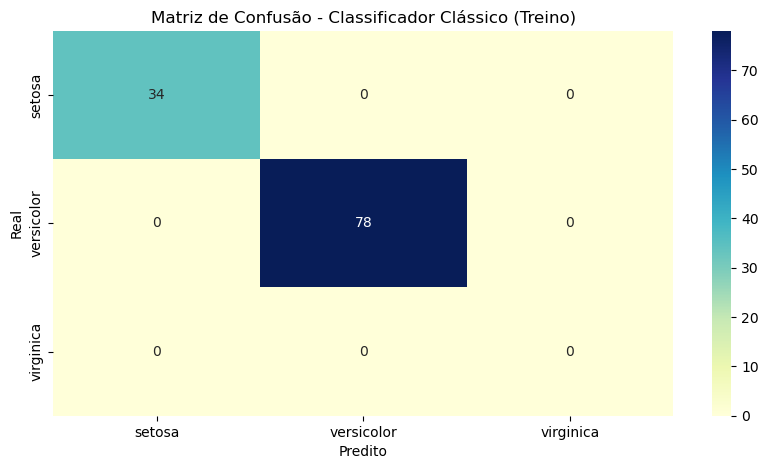

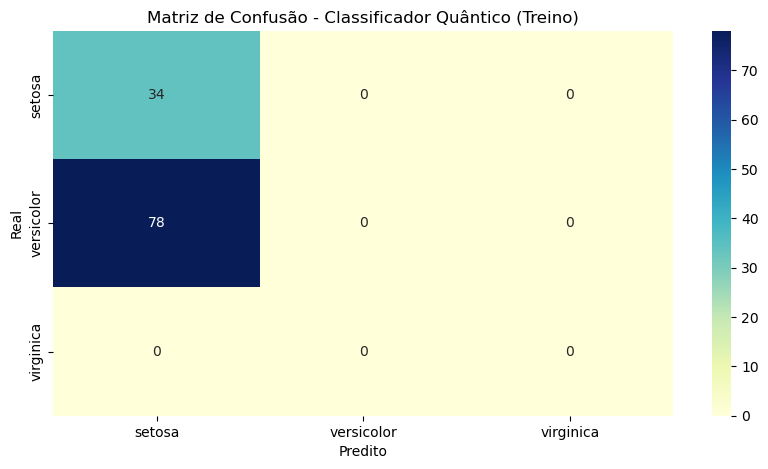

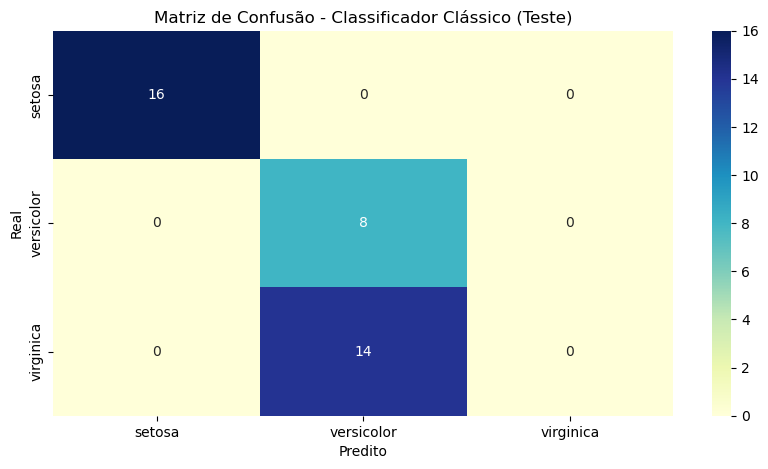

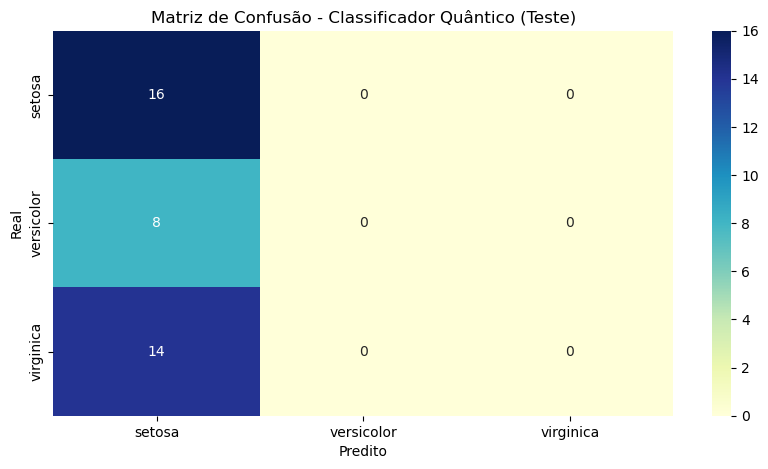

In [94]:
# Função para mostrar a matriz de confusão
def show_confusion_matrix(y_true, y_pred, classes, title):
    # Include all classes in the confusion matrix, even if some are missing in predictions
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    df_cm = pd.DataFrame(cm, columns=classes, index=classes)
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()

# Chamando a função para mostrar a matriz de confusão para os classificadores clássico e quântico
show_confusion_matrix(train_labels, train_predicts_classic, iris_data.target_names, 
                      "Matriz de Confusão - Classificador Clássico (Treino)")

show_confusion_matrix(train_labels, train_predicts_quantum, iris_data.target_names, 
                      "Matriz de Confusão - Classificador Quântico (Treino)")

show_confusion_matrix(test_labels, test_predicts_classic, iris_data.target_names, 
                      "Matriz de Confusão - Classificador Clássico (Teste)")

show_confusion_matrix(test_labels, test_predicts_quantum, iris_data.target_names, 
                      "Matriz de Confusão - Classificador Quântico (Teste)")

In [100]:
# Calculate specificity for each class
def calculate_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = np.sum(cm) - (np.sum(cm, axis=0) + np.sum(cm, axis=1) - np.diag(cm))
    fp = np.sum(cm, axis=0) - np.diag(cm)
    specificity = tn / (tn + fp)
    return np.mean(specificity)  # Macro average

<h3>Avaliação do comportamento do classificador em função do tamanho do conjunto de treinamento</h3>

Cost: 1.625465023945879, Parameters: [0.62357756 0.12931249 0.87940093 0.12522686 0.76060092 0.0359259
 0.25223372 0.88920304 0.25218365 0.56533721 0.06065926 0.01816566]
Cost: 1.6254650239458792, Parameters: [1.62357756 0.12931249 0.87940093 0.12522686 0.76060092 0.0359259
 0.25223372 0.88920304 0.25218365 0.56533721 0.06065926 0.01816566]
Cost: 1.6254650239458788, Parameters: [0.62357756 1.12931249 0.87940093 0.12522686 0.76060092 0.0359259
 0.25223372 0.88920304 0.25218365 0.56533721 0.06065926 0.01816566]
Cost: 1.6254650239458788, Parameters: [0.62357756 1.12931249 1.87940093 0.12522686 0.76060092 0.0359259
 0.25223372 0.88920304 0.25218365 0.56533721 0.06065926 0.01816566]
Cost: 1.625465023945879, Parameters: [0.62357756 1.12931249 0.87940093 1.12522686 0.76060092 0.0359259
 0.25223372 0.88920304 0.25218365 0.56533721 0.06065926 0.01816566]
Cost: 1.625465023945879, Parameters: [0.62357756 1.12931249 0.87940093 0.12522686 1.76060092 0.0359259
 0.25223372 0.88920304 0.25218365 0.565

C:\Users\Usuario\.conda\envs\qsvm_env\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Cost: 1.5979090385728152, Parameters: [0.35371847 0.68508961 0.27412831 0.95072236 0.38694252 0.72819147
 0.76905493 0.93435771 0.84271234 0.47473206 0.28605595 0.00352676]
Cost: 1.597909038572815, Parameters: [1.35371847 0.68508961 0.27412831 0.95072236 0.38694252 0.72819147
 0.76905493 0.93435771 0.84271234 0.47473206 0.28605595 0.00352676]
Cost: 1.5979090385728145, Parameters: [1.35371847 1.68508961 0.27412831 0.95072236 0.38694252 0.72819147
 0.76905493 0.93435771 0.84271234 0.47473206 0.28605595 0.00352676]
Cost: 1.597909038572815, Parameters: [1.35371847 1.68508961 1.27412831 0.95072236 0.38694252 0.72819147
 0.76905493 0.93435771 0.84271234 0.47473206 0.28605595 0.00352676]
Cost: 1.5979090385728145, Parameters: [1.35371847 1.68508961 0.27412831 1.95072236 0.38694252 0.72819147
 0.76905493 0.93435771 0.84271234 0.47473206 0.28605595 0.00352676]
Cost: 1.597909038572815, Parameters: [1.35371847 1.68508961 0.27412831 0.95072236 1.38694252 0.72819147
 0.76905493 0.93435771 0.84271234

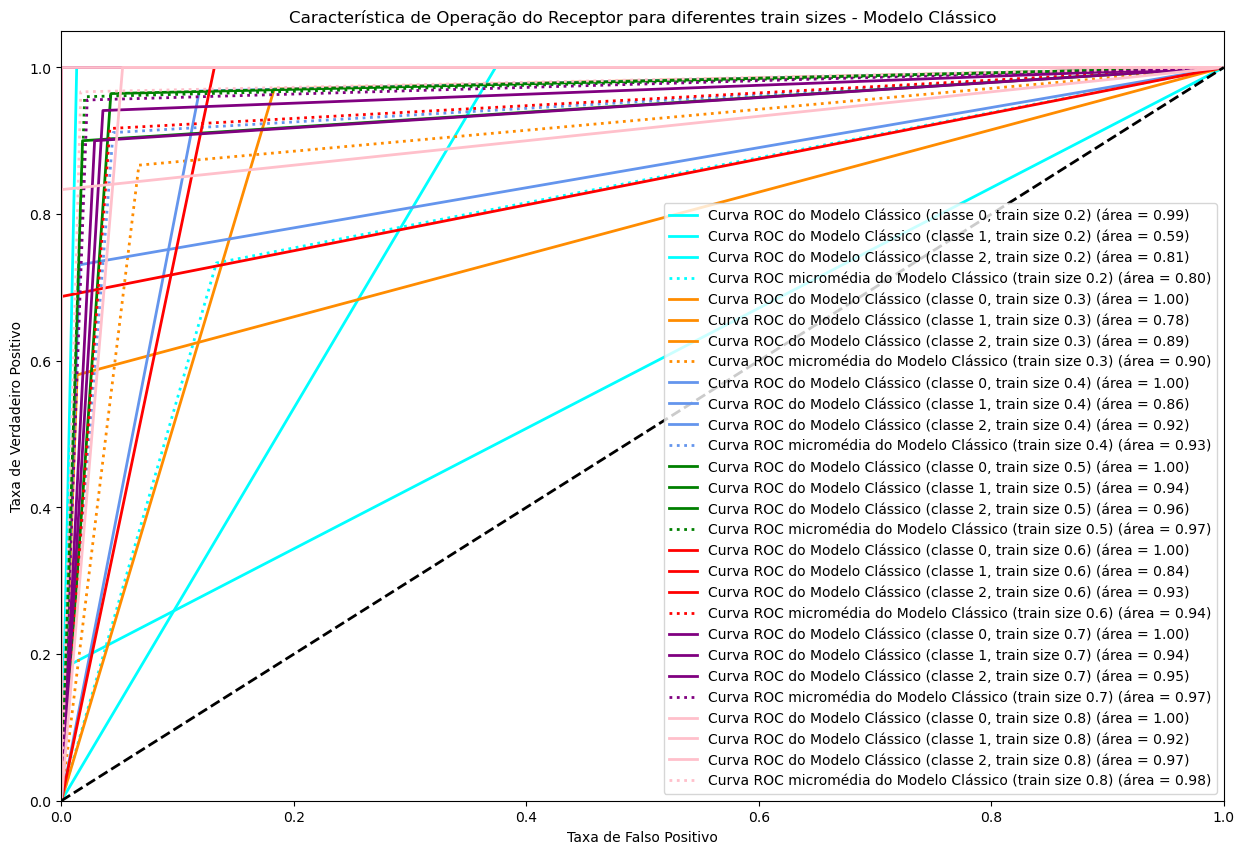

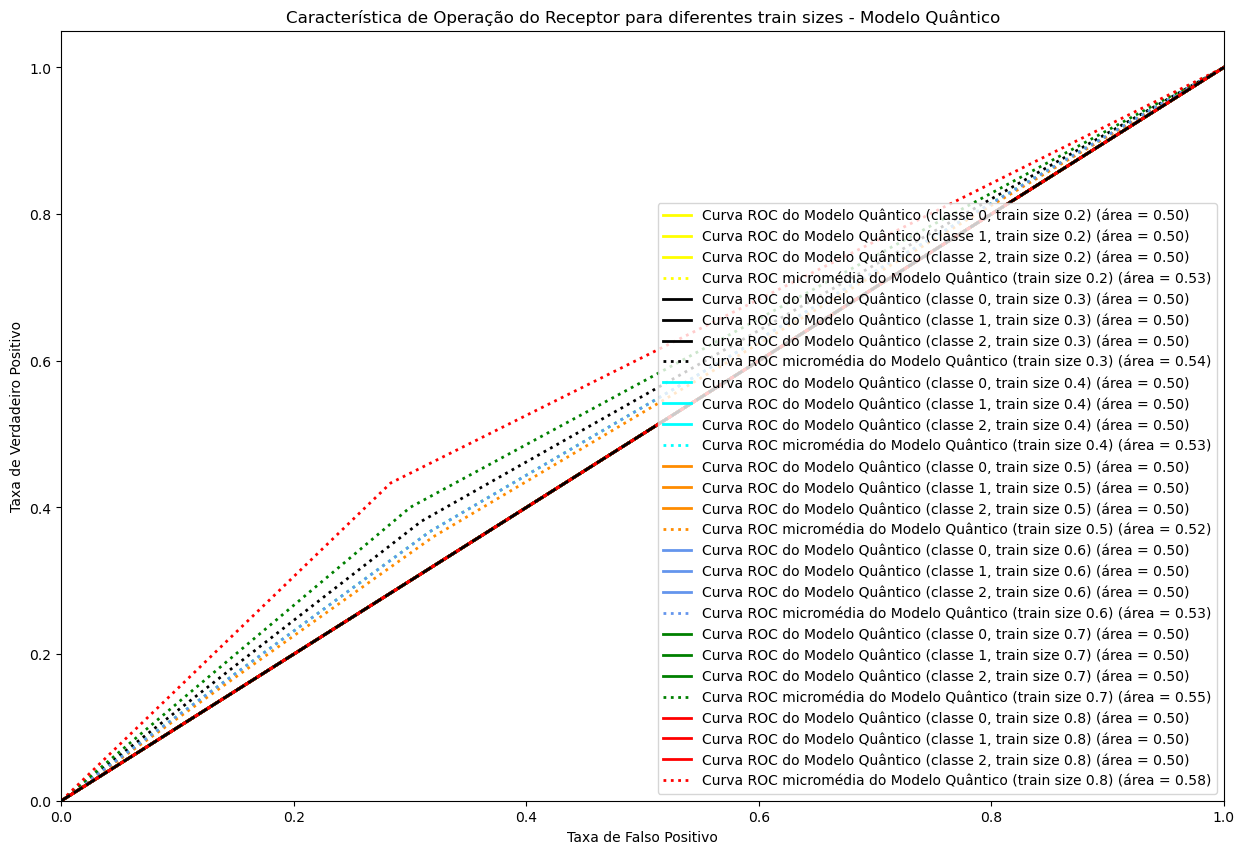

In [101]:
from prettytable import PrettyTable  # Import PrettyTable
# Inicialize a tabela de resultados
ptable = PrettyTable()
ptable.field_names = ["Train Size", "Model", "Train Accuracy", "Test Accuracy", "Train Specificity", "Test Specificity", "Train Recall", "Test Recall", "Train F1", "Test F1", "Train AUROC", "Test AUROC"]

train_sizes = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Inicializando os dicionários para armazenar os resultados
fpr_dict_classic = dict()
tpr_dict_classic = dict()
roc_auc_dict_classic = dict()

fpr_dict_quantum = dict()
tpr_dict_quantum = dict()
roc_auc_dict_quantum = dict()

# Definindo o ciclo de cores para as curvas ROC
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'pink', 'yellow', 'black'])

for train_size in train_sizes:
    # Split de treino e teste com o novo tamanho
    train_features, test_features, train_labels, test_labels = train_test_split(features, labels, train_size=train_size, random_state=TTS_seed)

    # Treinamento dos classificadores
    svc_classico = train_classic_classifier()
    vqc = train_quantum_classifier()

    # Previsões
    train_predicts_classic = svc_classico.predict(train_features)
    test_predicts_classic = svc_classico.predict(test_features)
    train_predicts_quantum = vqc.predict(train_features)
    test_predicts_quantum = vqc.predict(test_features)

    # Binarizando rótulos e previsões
    train_labels_bin = label_binarize(train_labels, classes=[*range(n_classes)])
    test_labels_bin = label_binarize(test_labels, classes=[*range(n_classes)])

    # Loop para cada modelo
    for i, (model_name, train_pred, test_pred) in enumerate([("Classical", train_predicts_classic, test_predicts_classic), ("Quantum", train_predicts_quantum, test_predicts_quantum)]):
        train_pred_bin = label_binarize(train_pred, classes=[*range(n_classes)])
        test_pred_bin = label_binarize(test_pred, classes=[*range(n_classes)])

        # Calculate ROC curve and ROC area for each class
        if model_name == "Classical":
            fpr_dict = fpr_dict_classic
            tpr_dict = tpr_dict_classic
            roc_auc_dict = roc_auc_dict_classic
        else:
            fpr_dict = fpr_dict_quantum
            tpr_dict = tpr_dict_quantum
            roc_auc_dict = roc_auc_dict_quantum

        fpr_dict[train_size] = dict()
        tpr_dict[train_size] = dict()
        roc_auc_dict[train_size] = dict()

        for j in range(n_classes):
            fpr_dict[train_size][j], tpr_dict[train_size][j], _ = roc_curve(test_labels_bin[:, j], test_pred_bin[:, j])
            roc_auc_dict[train_size][j] = auc(fpr_dict[train_size][j], tpr_dict[train_size][j])

        # Calcular micro-average curva ROC e área ROC
        fpr_dict[train_size]["micro"], tpr_dict[train_size]["micro"], _ = roc_curve(test_labels_bin.ravel(), test_pred_bin.ravel())
        roc_auc_dict[train_size]["micro"] = auc(fpr_dict[train_size]["micro"], tpr_dict[train_size]["micro"])

        # Convert one-hot encoded predictions back to class indices
        train_pred = np.argmax(train_pred, axis=1) if len(train_pred.shape) > 1 else train_pred
        test_pred = np.argmax(test_pred, axis=1) if len(test_pred.shape) > 1 else test_pred

        # Calculate the performance metrics
        train_accuracy = accuracy_score(train_labels, train_pred)
        test_accuracy = accuracy_score(test_labels, test_pred)
        train_specificity = calculate_specificity(train_labels, train_pred)
        test_specificity = calculate_specificity(test_labels, test_pred)
        train_recall = recall_score(train_labels, train_pred, average='micro')
        test_recall = recall_score(test_labels, test_pred, average='micro')
        train_f1 = f1_score(train_labels, train_pred, average='micro')
        test_f1 = f1_score(test_labels, test_pred, average='micro')
        train_auroc = np.mean([roc_auc_score(train_labels_bin[:, j], train_pred_bin[:, j]) for j in range(n_classes)])
        test_auroc = np.mean([roc_auc_score(test_labels_bin[:, j], test_pred_bin[:, j]) for j in range(n_classes)])


        # Adicionar os resultados à tabela
        ptable.add_row([train_size, model_name,
                        f"{train_accuracy:.3f}", f"{test_accuracy:.3f}",
                        f"{train_specificity:.3f}", f"{test_specificity:.3f}",
                        f"{train_recall:.3f}", f"{test_recall:.3f}",
                        f"{train_f1:.3f}", f"{test_f1:.3f}",
                        f"{train_auroc:.3f}", f"{test_auroc:.3f}"])

# Imprimir a tabela de resultados
print(ptable)

# Plotando curvas ROC pro clássico
plt.figure(figsize=(15,10))
for i, color in zip(fpr_dict_classic.keys(), colors):
    for j in range(n_classes):
        plt.plot(fpr_dict_classic[i][j], tpr_dict_classic[i][j], color=color, lw=2,
                 label=f'Curva ROC do Modelo Clássico (classe {j}, train size {i}) (área = {roc_auc_dict_classic[i][j]:0.2f})')
    plt.plot(fpr_dict_classic[i]["micro"], tpr_dict_classic[i]["micro"], color=color, lw=2, linestyle=':',
             label=f'Curva ROC micromédia do Modelo Clássico (train size {i}) (área = {roc_auc_dict_classic[i]["micro"]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Característica de Operação do Receptor para diferentes train sizes - Modelo Clássico')
plt.legend(loc="lower right")
plt.show()

# Plotando curvas ROC pro quântico
plt.figure(figsize=(15,10))
for i, color in zip(fpr_dict_quantum.keys(), colors):
    for j in range(n_classes):
        plt.plot(fpr_dict_quantum[i][j], tpr_dict_quantum[i][j], color=color, lw=2,
                 label=f'Curva ROC do Modelo Quântico (classe {j}, train size {i}) (área = {roc_auc_dict_quantum[i][j]:0.2f})')
    plt.plot(fpr_dict_quantum[i]["micro"], tpr_dict_quantum[i]["micro"], color=color, lw=2, linestyle=':',
             label=f'Curva ROC micromédia do Modelo Quântico (train size {i}) (área = {roc_auc_dict_quantum[i]["micro"]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Característica de Operação do Receptor para diferentes train sizes - Modelo Quântico')
plt.legend(loc="lower right")
plt.show()

In [2]:
from qiskit_aer import Aer
from qiskit.circuit.library import ZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import VQC